In [1]:
#TMDB Extract

In [2]:
from src.etl.extract import Extract

extractor = Extract()
data = extractor.fetch_movies(50)

len(data)
data[0]

Fetching pages: 50/50 | Movies: 1000 | Time: 11.5s


{'adult': False,
 'backdrop_path': '/dyJvKsNs2KP8qQnAXbRwDjblViy.jpg',
 'genre_ids': [16, 10751, 14],
 'id': 129,
 'original_language': 'ja',
 'original_title': '千と千尋の神隠し',
 'overview': 'A young girl, Chihiro, becomes trapped in a strange new world of spirits. When her parents undergo a mysterious transformation, she must call upon the courage she never knew she had to free her family.',
 'popularity': 29.7637,
 'poster_path': '/39wmItIWsg5sZMyRUHLkWBcuVCM.jpg',
 'release_date': '2001-07-20',
 'title': 'Spirited Away',
 'video': False,
 'vote_average': 8.5,
 'vote_count': 18156}

Basic Transform

In [3]:
from src.etl.transform import Transform

df = Transform.to_dataframe(data)

print(df.shape)
df.head()
df.describe()

Valid rows: 1000
Invalid rows skipped: 0
(1000, 9)


,movie_id,rating,popularity,release_year
count,1.000000e+03,1000.000000,1000.000000,999.000000
mean,2.287589e+05,6.759500,6.265320,2006.315315
std,3.004673e+05,0.716591,25.205884,16.149467
min,2.200000e+01,5.100000,0.006900,1922.000000
25%,1.026700e+04,6.200000,2.238475,1999.000000
50%,3.832000e+04,6.800000,3.649650,2010.000000
75%,4.320125e+05,7.300000,5.877275,2018.000000
max,1.311031e+06,8.500000,663.593700,2026.000000


In [4]:
df.isnull().sum()

movie_id        0
title           0
release_date    1
rating          0
popularity      0
genre_ids       0
genres          0
category        0
release_year    1
dtype: int64

In [5]:
df[df["release_date"].isnull()]

,movie_id,title,release_date,rating,popularity,genre_ids,genres,category,release_year
665,670355,Return,None,6.4,0.0261,"[18, 14]","Drama, Fantasy",Fantasy Epic,NaN


<Axes: title={'center': 'Movies per Year'}, xlabel='release_year'>

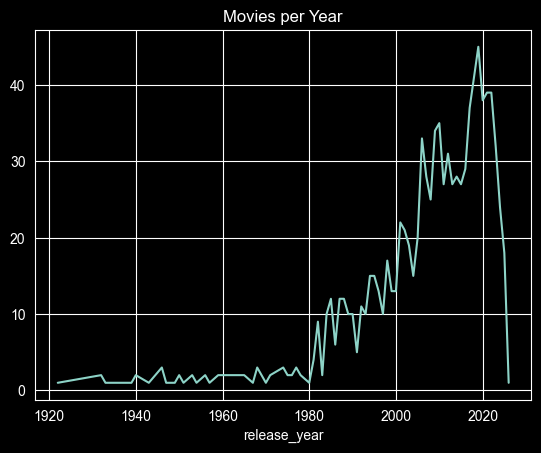

In [6]:
df.groupby("release_year").size().plot(title="Movies per Year")

In [7]:
df.sort_values(by="rating", ascending=False).head(10)[["title", "rating"]]

,title,rating
0,Spirited Away,8.5
1,The Green Mile,8.5
2,The Lord of the Rings: The Return of the King,8.5
3,The Lord of the Rings: The Fellowship of the Ring,8.4
4,A Dog's Will,8.4
5,The Lord of the Rings: The Two Towers,8.4
6,Howl's Moving Castle,8.4
7,Princess Mononoke,8.3
8,Chainsaw Man - The Movie: Reze Arc,8.3
9,Violet Evergarden: The Movie,8.3


In [8]:
import os
from dotenv import load_dotenv
import duckdb
from src.utils.paths import project_path

load_dotenv()
DUCKDB_PATH_ENV = os.getenv("DUCKDB_PATH", "data/db/movies.duckdb")
DB_PATH = project_path(DUCKDB_PATH_ENV)
print("Resolved DuckDB path:", DB_PATH)

# Connect and query
with duckdb.connect(DB_PATH) as con:
    df_db = con.execute("SELECT * FROM movies").fetchdf()
    df_db.head()

Resolved DuckDB path: C:\Users\strom\code\Grupp7_Datavisualisering_DE_UX\data\db\movies.duckdb


##Upcoming movies

In [9]:
from datetime import datetime

today = datetime.today().date()

unreleased = df[df["release_date"] > today]
unreleased.head()

,movie_id,title,release_date,rating,popularity,genre_ids,genres,category,release_year


Test case för top5 of movies

In [10]:
from src.etl.extract import Extract
from src.services.tmdb_service import TMDBService

service = TMDBService()
movies = extractor.fetch_movies(pages=25)

# Only enrich top X
for movie in movies[:3]:
    details = service.get_movie_details(movie["id"])
    print(details)

Fetching pages: 25/25 | Movies: 500 | Time: 5.6s
Cache hit for movie 129
movie_id=129 runtime=125 budget=19000000 revenue=274925095 overview='A young girl, Chihiro, becomes trapped in a strange new world of spirits. When her parents undergo a mysterious transformation, she must call upon the courage she never knew she had to free her family.' director='Hayao Miyazaki' last_updated=Timestamp('2026-04-16 17:33:29.612155')
Cache hit for movie 497
movie_id=497 runtime=189 budget=60000000 revenue=286801374 overview="A supernatural tale set on death row in a Southern prison, where gentle giant John Coffey possesses the mysterious power to heal people's ailments. When the cell block's head guard, Paul Edgecomb, recognizes Coffey's miraculous gift, he tries desperately to help stave off the condemned man's execution." director='Frank Darabont' last_updated=Timestamp('2026-04-16 17:33:30.100949')
Cache hit for movie 122
movie_id=122 runtime=201 budget=94000000 revenue=1118888979 overview='As ar

In [11]:
from src.repository.movie_repository import MovieRepository

with MovieRepository(DB_PATH) as repo:
    print(repo.conn.execute("SHOW TABLES").fetchall())


[('genres',), ('movie_cast',), ('movie_crew',), ('movie_details',), ('movie_genres',), ('movies',)]


In [12]:
for movie in movies[:3]:
    details = service.get_movie_details(movie["id"])

    print(
        details.movie_id,
        details.runtime,
        details.director
    )

Cache hit for movie 129
129 125 Hayao Miyazaki
Cache hit for movie 497
497 189 Frank Darabont
Cache hit for movie 122
122 201 Peter Jackson


Grab from the database so we can include cast and crew.

In [13]:
from src.etl.extract import Extract
from src.services.tmdb_service import TMDBService

service = TMDBService()
movies = extractor.fetch_movies(pages=25)

# top 5 from the cached database including full cast and crew
for movie in movies[:5]:
    details = service.repo.get_full_movie_details(movie["id"])
    print(details)

Fetching pages: 25/25 | Movies: 500 | Time: 5.6s
{'movie': {'movie_id': 129, 'runtime': 125, 'budget': 19000000, 'revenue': 274925095, 'overview': 'A young girl, Chihiro, becomes trapped in a strange new world of spirits. When her parents undergo a mysterious transformation, she must call upon the courage she never knew she had to free her family.', 'director': 'Hayao Miyazaki', 'last_updated': Timestamp('2026-04-16 17:33:29.612155')}, 'cast':             actor_name                character  cast_order
0         Rumi Hiiragi          Chihiro (voice)           0
1           Miyu Irino             Haku (voice)           1
2         Mari Natsuki  Yubaba / Zeniba (voice)           2
3        Takashi Naito           Father (voice)           3
4     Yasuko Sawaguchi           Mother (voice)           4
5      Tatsuya Gashûin          Aogaeru (voice)           5
6     Ryunosuke Kamiki              Boh (voice)           6
7           Yumi Tamai              Rin (voice)           7
8           